#  Karar Ağaçları (Decision Trees)

Karar ağaçları, hem sınıflandırma hem de regresyon problemlerini çözbilen, çok yönlü makine öğrenmesi algoritmasıdır. Karar ağaçlarının ana avantajları:

✅ Yorumlanabilirlik: "White Box" modeldirler - nasıl karar aldıklarını anlamaları kolaydır

✅ Veri Hazırlama: Ölçeklendirme (scaling) gerektirmez

✅ Esneklik: Doğrusal olmayan ilişkileri öğrenebilir

✅ Hız: Tahmin yapmak çok hızlıdır

❌ Aşırı Uyum: Eğitim verisine aşırı uyma eğilimi gösterir

❌ Veri Duyarlılığı: Küçük veri değişiklikleri ağacı drastik şekilde değiştirebilir

## Düğüm (Node) Türleri
### 1. Kök Düğüm (Root Node)

Ağacın en üst kısmında bulunan düğümdür
İlk karar burada verilir
Tüm eğitim verisiyle başlar

### 2. Bölüm Düğümü (Split Node)

Bir soruyu sorar ve veriyi iki alt gruba böler
Örnek: "Petal uzunluğu 2.45 cm'den az mı?"
Sol veya sağa gider

### 3. Yaprak Düğüm (Leaf Node)

Ağacın alt ucundaki düğümlerdir
Soru sormazlar, sadece sınıf tahmini yapmazlar
Tahmin sona erer

## Karar Ağacı Oluşturma ve Görselleştirme

---Adım 1: Gerekli Kütüphaneleri İçeri Aktar---

In [22]:
from sklearn.datasets import load_iris      # Iris veri setini yükle
from sklearn.tree import DecisionTreeClassifier  # Karar ağacı sınıflandırıcısı
import numpy as np                          # Sayısal işlemler
import matplotlib.pyplot as plt             # Grafik çizme

load_iris(): Iris çiçekleri veri setini yükler (150 örnek, 4 özellik)

DecisionTreeClassifier: Scikit-Learn'ün karar ağacı sınıflandırıcısı

numpy: Matematik ve diziler için

matplotlib: Görselleri çizmek için

---Adım 2: Veriyi Yükle ve Hazırla---

In [23]:
iris = load_iris(as_frame=True)
# as_frame=True: Veriler DataFrame formatında gelir

In [24]:
# Sadece petal (taç yaprakları) özelliklerini seç
X_iris = iris.data[["petal length (cm)", "petal width (cm)"]].values
# X_iris: 150 satır, 2 sütundan oluşan dizi

y_iris = iris.target
# y_iris: Her örneğin sınıfı (0=setosa, 1=versicolor, 2=virginica)

Neden sadece 2 özellik seçtik?

2D grafiklerde görmek daha kolay

Karar sınırlarını görselleştirmek mümkün

### ---Veri Yapısı:--

In [25]:
# Karar ağacı sınıflandırıcısı oluştur
tree_clf = DecisionTreeClassifier(
    max_depth=2,      # Maksimum derinlik = 2 (3 seviye: 0, 1, 2)
    random_state=42   # Tekrarlanabilirlik için rasgele sayı tohumunu sabitle
)

# Modeli veriler üzerinde eğit
tree_clf.fit(X_iris, y_iris)
# fit() fonksiyonu: 
# - Eğitim verisi (X_iris) ve hedef (y_iris) kullanarak ağacı oluşturur
# - Her düğümde en iyi bölme noktasını bulur
# - max_depth'e kadar derinleşir

DecisionTreeClassifier(max_depth=2, random_state=42)

## Hiperparametreler:

Tahmin Yapma,
Bir Örnek Tahmin Et


In [26]:
# Petal uzunluğu 5cm, genişliği 1.5cm olan bir çiçek
tahmin = tree_clf.predict([[5, 1.5]])
print(tahmin)  # Çıktı: [1] (Iris versicolor)

[1]


## Ağaç İçinde Nasıl Gitti?

### - --Tahmin Çıktı Detayları---

In [27]:
# Her adımdaki bilgi:
# Root: [0, 50, 100] → 50 setosa, 100 other
# Leaf: [0, 49, 5] → 49 versicolor, 5 virginica

# En yüksek sayı olan sınıf seçilir → 49 versicolor → Sınıf 1

In [28]:
# Aynı örnek için olasılıkları al
olasiliklar = tree_clf.predict_proba([[5, 1.5]])
print(olasiliklar.round(3))
# Çıktı: [[0.0, 0.907, 0.093]]
#        Setosa: 0%  |  Versicolor: 90.7%  |  Virginica: 9.3%

[[0.    0.907 0.093]]


Olasılıklar Nasıl Hesaplanır?

Yaprak düğümde ulaşan eğitim örneklerinden:

Setosa örnekleri: 0 / 54 = 0.0

Versicolor örnekleri: 49 / 54 = 0.907

Virginica örnekleri: 5 / 54 = 0.093

Önemli Not: Aynı yaprak düğüme ulaşan tüm örnekler aynı olasılıklara sahip olur!

Örneğin [6, 1.5] ve [5, 1.5] de aynı yaprak düğüme ulaşır

Bu da aynı olasılıkları verir (bu bir sınırlılıktır)



## CART Algoritması

CART = Classification and Regression Tree (Sınıflandırma ve Regresyon Ağacı)

Scikit-Learn tarafından kullanılan algoritma CART'tır.



### Maliyeti Hesaplamak

In [98]:

# İlk durum
örnekler = [50, 50, 50]
toplam = 150

# Bölüş: petal_length ≤ 2.45
sol_örnekler = [50, 0, 0]
sağ_örnekler = [0, 50, 50]

# Gini'leri hesapla
G_sol = gini_impurity(sol_örnekler)  # = 0.0 (saf!)
G_sağ = gini_impurity(sağ_örnekler)  # = 0.5 (karışık)

# Toplam Maliyet
m_sol = 50
m_sağ = 100
m_toplam = 150

J = (m_sol / m_toplam) * G_sol + (m_sağ / m_toplam) * G_sağ
J = (50 / 150) * 0.0 + (100 / 150) * 0.5
J = 0 + 0.333
J = 0.333  # ← İyi bir bölüş!

## ---Gini Impurity Kavramı---

Örnek Hesaplama

In [91]:
# Python Kod
import numpy as np
örnekler = [0, 49, 5]
total = sum(örnekler)
oranlar = [x/total for x in örnekler]
gini = 1 - sum(p**2 for p in oranlar)
print(f"Gini = {gini:.3f}")  # 0.169

Gini = 0.168


In [90]:
import numpy as np

def gini_impurity(örnekler):
    """
    Gini İmpariteleri Hesapla
    
    Parametreler:
        örnekler: Sınıf sayılarının list'i [n_class_0, n_class_1, ...]
    
    Döndürür:
        Gini impurity değeri (0 ile 1 arasında)
    """
    toplam = np.sum(örnekler)
    
    if toplam == 0:
        return 0
    
    # Her sınıfın oranını hesapla
    oranlar = örnekler / toplam
    
    # Oranların karesinin toplamını hesapla
    kare_toplamı = np.sum(oranlar ** 2)
    
    # Gini = 1 - Σ(p_k)²
    gini = 1 - kare_toplamı
    
    return gini

# Örnekler
print(f"Saf: {gini_impurity([50, 0, 0]):.3f}")      # 0.0
print(f"Karışık: {gini_impurity([0, 49, 5]):.3f}")  # 0.168
print(f"Çok Karışık: {gini_impurity([10, 10, 10]):.3f}")  # 0.667

Saf: 0.000
Karışık: 0.168
Çok Karışık: 0.667


Neden Gini Kullanırız?

✅ Hızlı hesapla

✅ Çeşitli algoritmalarda kanıtlanmış

✅ Alternatif: Entropy (benzer sonuçlar verir)

## ENTROPİ KAVRAMI

Tanım

Bilgi teorisinden gelmiş başka bir impurity ölçüsüdür.

Formül:

In [100]:
# Python'da entropi hesaplama
import numpy as np
import math

def entropi(örnekler):
    toplam = np.sum(örnekler)
    if toplam == 0:
        return 0
    
    oranlar = örnekler / toplam
    # p × log(p) için p ≠ 0 şartı
    entropi = 0
    for p in oranlar:
        if p > 0:
            entropi -= p * math.log2(p)
    
    return entropi

# Karşılaştırma
örnekler = np.array([0, 49, 5])

gini = 1 - np.sum((örnekler / 54) ** 2)
ent = entropi(örnekler)

print(f"Gini:    {gini:.3f}")      # 0.168
print(f"Entropi: {ent:.3f}")       # 0.445

Gini:    0.168
Entropi: 0.445


Python'da Entropy kullanmak:

In [30]:
tree_clf = DecisionTreeClassifier(
    max_depth=2,
    criterion='entropy',  # Gini yerine Entropy
    random_state=42
)
tree_clf.fit(X_iris, y_iris)

DecisionTreeClassifier(criterion='entropy', max_depth=2, random_state=42)

 ###  --Entropi Örneği---

In [31]:
# Örnek düğüm
örnekler = [0, 49, 5]
total = 54
oranlar = [0/54, 49/54, 5/54]

# p_k ≠ 0 olanlar için
p1 = 49/54  # 0.907
p2 = 5/54   # 0.093

import math
H = -(p1 * math.log2(p1) + p2 * math.log2(p2))
print(f"Entropi = {H:.3f}")  # 0.445

Entropi = 0.445


## KARAR SINIRI (DECISION BOUNDARY)

### Karar Sınırı Nedir?
Karar ağacı iki özelliği olan veri setinde, sınıfları ayıran çizgiler çizer.

## Eksen-Hizalı Bölüş (Axis-Aligned Splits)
### CART algoritmasının sınırlaması:

### Çözüm: PCA ile Veri Döndürme


In [101]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# 1. Standart Hale Getir (0 ortalama, 1 std)
# 2. PCA ile Döndür (veriye uygun eksenler)
# 3. Karar Ağacı Eğit

pipeline = make_pipeline(StandardScaler(), PCA())
X_transformed = pipeline.fit_transform(X_iris)

tree = DecisionTreeClassifier(max_depth=2)
tree.fit(X_transformed, y_iris)
# Artık daha iyi bölünüş yapabilir!

DecisionTreeClassifier(max_depth=2)

## Düzenlileştirme (Regularization)

Problem: Aşırı Uyum (Overfitting)

Sınırlandırması olmayan karar ağaçları eğitim verisine çok iyi uyar ama test verisine kötü uyar!

Çözüm: Düzenlileştirme Hiperparametreleri

###  1. max_depth (Maksimum Derinlik)

In [32]:
# Aşırı Uyum (Overfitting)
tree_overfit = DecisionTreeClassifier(max_depth=10)
# Ağaç çok derin, eğitim verisine aşırı uyum

# Düzenlileştirilmiş
tree_better = DecisionTreeClassifier(max_depth=3)
# Daha dengeli ağaç

### 2. min_samples_split (Minimum Bölüm Örneği)

In [33]:
# Çok düşük - aşırı uyum riski
tree_split = DecisionTreeClassifier(min_samples_split=2)

# İyi seçim - genelleme
tree_split = DecisionTreeClassifier(min_samples_split=5)
# Bölünmeden önce en az 5 örnek gerekli

### 3. min_samples_leaf (Minimum Yaprak Örneği)

In [34]:
# Yaprak düğümde en az kaç örnek olması gerekir
tree_leaf = DecisionTreeClassifier(min_samples_leaf=5)

# Örnek: Düğüm 10 örneğe sahipse
# - Bölünürse sol 9, sağ 1 → Başarısız (1 < 5)
# - Bölüş iptal edilir, yaprak olarak kalır

### 4. max_leaf_nodes (Maksimum Yaprak Sayısı)


In [35]:
# Ağaçta en fazla 30 yaprak düğüm olsun
tree_nodes = DecisionTreeClassifier(max_leaf_nodes=30)

### ----Pratik Örnek----

In [36]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Ay şeklinde veri seti oluştur
X_moons, y_moons = make_moons(n_samples=150, noise=0.2, random_state=42)

# Eğitim ve test verilerine böl
X_train, X_test, y_train, y_test = train_test_split(
    X_moons, y_moons, test_size=0.2, random_state=42
)

# Aşırı Uyum Yapan Model
tree_overfit = DecisionTreeClassifier(random_state=42)
tree_overfit.fit(X_train, y_train)
print(f"Eğitim: {tree_overfit.score(X_train, y_train):.3f}")  # 1.000
print(f"Test: {tree_overfit.score(X_test, y_test):.3f}")      # 0.800

# Düzenlileştirilmiş Model
tree_regular = DecisionTreeClassifier(
    min_samples_leaf=5,  # En az 5 örnek yaprak'ta
    random_state=42
)
tree_regular.fit(X_train, y_train)
print(f"Eğitim: {tree_regular.score(X_train, y_train):.3f}")  # 0.950
print(f"Test: {tree_regular.score(X_test, y_test):.3f}")      # 0.850

# Düzenlileştirme yardımcı oldu! ✓

Eğitim: 1.000
Test: 0.900
Eğitim: 0.917
Test: 0.833


## Regresyon Ağacı Oluşturma

In [37]:
from sklearn.tree import DecisionTreeRegressor
import numpy as np

# Basit ikinci dereceden veri seti oluştur
rng = np.random.default_rng(seed=42)
X_quad = rng.random((200, 1)) - 0.5  # -0.5 ile 0.5 arasında 200 değer
y_quad = X_quad ** 2 + 0.025 * rng.standard_normal((200, 1))
# y = x² + küçük gürültü

# Regresyon Ağacı Eğit
tree_reg = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_reg.fit(X_quad, y_quad)

# Tahmin Yap
X_test = np.array([[0.0], [0.25], [-0.25]])
tahmin = tree_reg.predict(X_test)
print(tahmin)

[0.03758823 0.03758823 0.03758823]


Regresyon Nasıl Çalışır?

Sınıflandırmada:

Her yaprak düğüm: Sınıf etiketi

Tahmin: En sık görülen sınıf



Regresyonda:

Her yaprak düğüm: Sayısal Değer (ortalama)

Tahmin: Yaprak düğümündeki eğitim örneklerinin ortalaması

In [38]:
# Örnek
# Yaprak düğüme ulaşan eğitim örnekleri: [0.15, 0.22, 0.18]
# Tahmin = (0.15 + 0.22 + 0.18) / 3 = 0.183

### Regresyon Bölüş Kriteri


Sınıflandırmada Gini/Entropy yerine, regresyon için MSE (Mean Squared Error) kullanılır:


## Eğitim vs Test Performansı

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Veri böl
X_train, X_test, y_train, y_test = train_test_split(
    X_quad, y_quad, test_size=0.2, random_state=42
)

# Aşırı Uyum Yapan Model
tree_deep = DecisionTreeRegressor(max_depth=10)
tree_deep.fit(X_train, y_train)

train_mse = mean_squared_error(y_train, tree_deep.predict(X_train))
test_mse = mean_squared_error(y_test, tree_deep.predict(X_test))

print(f"Eğitim MSE: {train_mse:.4f}")  # Çok düşük
print(f"Test MSE: {test_mse:.4f}")      # Çok yüksek

# Düzenlileştirilmiş Model
tree_regular = DecisionTreeRegressor(max_depth=3)
tree_regular.fit(X_train, y_train)

train_mse = mean_squared_error(y_train, tree_regular.predict(X_train))
test_mse = mean_squared_error(y_test, tree_regular.predict(X_test))

print(f"Eğitim MSE: {train_mse:.4f}")  # Makul
print(f"Test MSE: {test_mse:.4f}")      # Daha düşük - iyi!

Eğitim MSE: 0.0001
Test MSE: 0.0013
Eğitim MSE: 0.0009
Test MSE: 0.0011


 ## Eksen Yönelimi Duyarlılığı

Problem

Karar ağaçları sadece eksenle hizalı bölünüşler yapabilirler (dikey/yatay çizgiler).

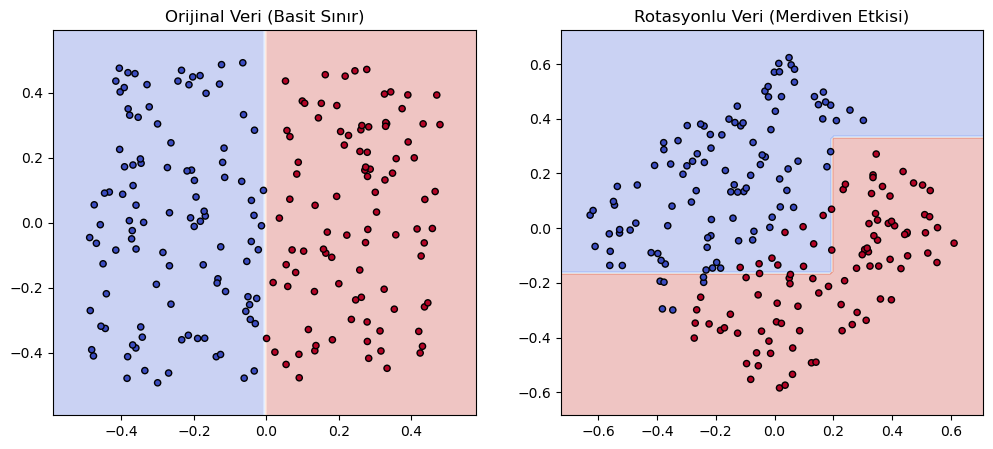

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier

# 1. Veri Hazırlığı
rng = np.random.default_rng(seed=42)
X_square = rng.random((200, 2)) - 0.5  # [-0.5, 0.5] aralığı

# Hata alınan yer: y_square değişkenini tanımlıyoruz.
# Örneğin: x-ekseninde 0'dan büyük olanlar 1, küçük olanlar 0 olsun.
y_square = (X_square[:, 0] > 0).astype(int)

# Veriyi 45 derece döndür
angle = np.pi / 4  # 45 derece
rotation_matrix = np.array([
    [np.cos(angle), -np.sin(angle)],
    [np.sin(angle), np.cos(angle)]
])
X_rotated = X_square.dot(rotation_matrix)

# 2. Modelleri Eğitme
# Orijinal veri seti: Karar ağacı dikey bir çizgiyle kolayca ayırabilir.
tree_normal = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_normal.fit(X_square, y_square)

# Rotasyonlu veri seti: Sınır artık 45 derece olduğu için ağaç zorlanacaktır.
tree_rotated = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_rotated.fit(X_rotated, y_square)

# 3. Karar Sınırlarını Görselleştirme Fonksiyonu
def plot_decision_boundary(clf, X, y, ax, title):
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='coolwarm', s=20)
    ax.set_title(title)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
plot_decision_boundary(tree_normal, X_square, y_square, ax1, "Orijinal Veri (Basit Sınır)")
plot_decision_boundary(tree_rotated, X_rotated, y_square, ax2, "Rotasyonlu Veri (Merdiven Etkisi)")
plt.show()

Veriyi önceden döndürün:

In [42]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Pipeline oluştur: Standart hale getir → PCA → Karar Ağacı
pipeline = make_pipeline(
    StandardScaler(),      # 0 ortalaması, 1 std'ye ölçekle
    PCA(),                 # Veriye uygun açıya döndür
)

# Veriyi dönüştür
X_transformed = pipeline.fit_transform(X_iris)

# Döndürülmüş veriye ağaç eğit
tree_pca = DecisionTreeClassifier(max_depth=2)
tree_pca.fit(X_transformed, y_iris)
# Artık daha verimlilerdir!

DecisionTreeClassifier(max_depth=2)

## Ağaç Yapısına Erişim

 ###  tree_ Attribute


Eğitilmiş ağacın iç yapısına erişebilirsiniz:


In [43]:
tree = tree_clf.tree_

# Genel bilgiler
print(f"Düğüm sayısı: {tree.node_count}")        # 7
print(f"Maksimum derinlik: {tree.max_depth}")    # 2
print(f"Sınıf sayısı: {tree.max_n_classes}")     # 3
print(f"Özellik sayısı: {tree.n_features}")      # 2
print(f"Yaprak düğüm sayısı: {tree.n_leaves}")   # 4

Düğüm sayısı: 5
Maksimum derinlik: 2
Sınıf sayısı: 3
Özellik sayısı: 2
Yaprak düğüm sayısı: 3


### Düğümleri Gezme

In [46]:
tree = tree_clf.tree_

# Tüm düğümlerin Gini impurity değerleri
print(tree.impurity)
# [0.666, 0.0, 0.168, ...]

# Kök düğümün (node 0) çocuklarını bul
left_child = tree.children_left[0]   # Sol çocuk indeksi
right_child = tree.children_right[0] # Sağ çocuk indeksi
print(f"Sol: {left_child}, Sağ: {right_child}")

# Yaprak düğümleri bul
is_leaf = tree.children_left == tree.children_right
leaf_indices = np.arange(tree.node_count)[is_leaf]
print(f"Yaprak düğümleri: {leaf_indices}")  # [1, 3, 4]

[1.5849625  0.         1.         0.44506486 0.15109697]
Sol: 1, Sağ: 2
Yaprak düğümleri: [1 3 4]


### Bölüş Bilgisi

In [47]:
tree = tree_clf.tree_

# Her düğümü bölen özelliği
print(tree.feature)    # [0, -2, 1, -2, -2]
#                        Feature 0: petal length
#                        Feature 1: petal width
#                        -2: Yaprak düğüm (bölmez)

# Bölüş eşik değerleri
print(tree.threshold)  # [2.449, -2., 1.75, -2., -2.]

[ 0 -2  1 -2 -2]
[ 2.44999999 -2.          1.75       -2.         -2.        ]


### Örnek ve Sınıf Bilgisi

In [48]:
# Her düğüme ulaşan örnek sayısı
print(tree.n_node_samples)
# [150, 50, 100, 54, 46, 1, 99]
#  Kök'te 150 örnek
#  Sol çocukta 50 örnek
#  Sağ çocukta 100 örnek
#  ...

# Her düğümdeki sınıf dağılımı
print(tree.value)
# [[[50, 50, 50]],      # Kök: 50 setosa, 50 versicolor, 50 virginica
#  [[50, 0, 0]],        # Sol yaprak: 50 setosa
#  [[0, 50, 50]],       # Sağ alt ağaç kökü
#  [[0, 49, 5]],        # ...
#  ...]

[150  50 100  54  46]
[[[50. 50. 50.]]

 [[50.  0.  0.]]

 [[ 0. 50. 50.]]

 [[ 0. 49.  5.]]

 [[ 0.  1. 45.]]]


### Derinlik Hesaplama

In [49]:
def compute_depth(tree_clf):
    """Ağaçta her düğümün derinliğini hesapla"""
    tree = tree_clf.tree_
    depth = np.zeros(tree.node_count)
    stack = [(0, 0)]  # (düğüm_indeksi, derinlik)
    
    while stack:
        node, node_depth = stack.pop()
        depth[node] = node_depth
        
        # Leaf olmayan düğümler çocuk ekle
        if tree.children_left[node] != tree.children_right[node]:
            left = tree.children_left[node]
            right = tree.children_right[node]
            stack.append((left, node_depth + 1))
            stack.append((right, node_depth + 1))
    
    return depth

depth = compute_depth(tree_clf)
print(depth)  # [0, 1, 1, 2, 2, 2, 2]
#              Derinlik: 0, 1, 1, 2, 2, 2, 2

[0. 1. 1. 2. 2.]


### Belirli Derinlikteki Bölünüşleri Bul


In [50]:
tree = tree_clf.tree_
depth = compute_depth(tree_clf)
is_leaf = tree.children_left == tree.children_right

# Derinlik 1'deki bölüm düğümleri
split_nodes_depth1 = (depth == 1) & (~is_leaf)
print(tree.feature[split_nodes_depth1])    # [1]
print(tree.threshold[split_nodes_depth1])  # [1.75]
# Derinlik 1'de: petal width ≤ 1.75 bölünüşü var

[1]
[1.75]


## Pratik Örnek - Ay Veri Seti

### Adım 1: Ay Veri Seti Oluştur


In [52]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score

# Ay şeklinde 10000 örnek oluştur
X_moons, y_moons = make_moons(
    n_samples=10000,      # 10000 örnek
    noise=0.4,            # Gürültü ekle (daha zor)
    random_state=42       # Tekrarlanabilirlik
)

print(f"Veri şekli: {X_moons.shape}")      
print(f"Hedef şekli: {y_moons.shape}")    
print(f"Sınıflar: {np.unique(y_moons)}")  

Veri şekli: (10000, 2)
Hedef şekli: (10000,)
Sınıflar: [0 1]


### Adım 2: Eğitim/Test Verilerine Böl

In [55]:
# %80 eğitim, %20 test
X_train, X_test, y_train, y_test = train_test_split(
    X_moons, y_moons,
    test_size=0.2,        # %20 test
    random_state=42
)

print(f"Eğitim verisi: {X_train.shape}")
print(f"Test verisi: {X_test.shape}")      

Eğitim verisi: (8000, 2)
Test verisi: (2000, 2)


### Adım 3: Grid Search ile Hiperparameter Tuning
Grid Search, en iyi hiperparametreleri bulmak için tüm kombinasyonları dener:

In [56]:
# Denenecek hiperparametreler
param_grid = {
    'max_leaf_nodes': list(range(2, 100)),  # 2-99 yaprak düğüm
    'max_depth': [1, 2, 3, 4, 5, 6],       # 1-6 derinlik
    'min_samples_split': [2, 3, 4]         # 2-4 minimum örnek
}

# Grid Search başlat
grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=3                                    # 3 kat çapraz doğrulama
)

# Tüm kombinasyonları dene
grid_search.fit(X_train, y_train)

# En iyi hiperparametreleri al
print(f"En iyi parametreler: {grid_search.best_params_}")
# Örneğin:
# {'max_depth': 4, 'max_leaf_nodes': 20, 'min_samples_split': 2}

print(f"En iyi CV Skoru: {grid_search.best_score_:.3f}")

En iyi parametreler: {'max_depth': 6, 'max_leaf_nodes': 17, 'min_samples_split': 2}
En iyi CV Skoru: 0.854


### Adım 4: Test Verisiyle Değerlendir

In [57]:
# GridSearchCV otomatik olarak en iyi modeli eğitir
best_clf = grid_search.best_estimator_

# Test doğruluğu
y_pred = best_clf.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)

print(f"Test Doğruluğu: {test_accuracy:.3f}")
# Tipik olarak %85-87 arasında

Test Doğruluğu: 0.860


### Adım 5: Tahmin Yap


In [58]:
# Yeni örnek için tahmin
new_sample = np.array([[0.5, 0.5]])
prediction = best_clf.predict(new_sample)
probability = best_clf.predict_proba(new_sample)

print(f"Sınıf: {prediction[0]}")           # 0 veya 1
print(f"Olasılıklar: {probability[0]}")    # [0.3, 0.7] gibi

Sınıf: 0
Olasılıklar: [0.77212121 0.22787879]


### Random Forest (Bonus)
Karar ağaçları çok duyarlı olabilir. Bunu çözmek için birden fazla ağacı kombinleyin:

### Random Forest Fikri
Ağaç 1: Tahmin = A sınıfı

Ağaç 2: Tahmin = B sınıfı

Ağaç 3: Tahmin = A sınıfı

...

Ağaç 100: Tahmin = A sınıfı

Sonuç: Çoğunluk oyu = A sınıfı ✓

### Kod:

In [59]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest: 100 ağaçtan oluşur
rf = RandomForestClassifier(
    n_estimators=100,     # 100 ağaç
    max_depth=4,          # Her ağaç 4 derinlik
    random_state=42
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Random Forest Doğruluğu: {accuracy:.3f}")
# Genellikle tek ağaçtan daha iyi!

Random Forest Doğruluğu: 0.868


## İRİS VERİ SETİ KULLANARAK KONU AÇIKLAMASINDA KULLANILAN ÖRNEĞİN TAM VE DETAYLI ANLATIMLI HALİ

### BÖLÜM 1: TEMEL SETUP VE İTHALATLAR

In [61]:
print("=" * 80)
print("BÖLÜM 1: SETUP VE KÜTÜPHANE İTHALATLARI")
print("=" * 80)

import numpy as np                          # Sayısal işlemler (diziler, matematik)
import matplotlib.pyplot as plt             # Grafik çizme
from sklearn.datasets import load_iris     # Iris veri setini yükle
from sklearn.tree import DecisionTreeClassifier  # Karar ağacı sınıflandırıcısı
from sklearn.tree import export_graphviz    # Ağacı görselleştirmek için
from sklearn.metrics import accuracy_score  # Model doğruluğu ölçü

# Matplotlib ayarları - grafikler daha güzel görünsün diye
plt.rc('font', size=14)                    # Yazı boyutu 14
plt.rc('axes', labelsize=14, titlesize=14) # Eksen başlıkları 14
plt.rc('legend', fontsize=14)              # Legend 14
plt.rc('xtick', labelsize=10)              # X ekseni 10
plt.rc('ytick', labelsize=10)              # Y ekseni 10

print("✓ Tüm kütüphaneler başarıyla yüklendi\n")

BÖLÜM 1: SETUP VE KÜTÜPHANE İTHALATLARI
✓ Tüm kütüphaneler başarıyla yüklendi



In [62]:
print("=" * 80)
print("BÖLÜM 2: VERİ YÜKLEME VE HAZIRLAMA")
print("=" * 80)

# İris veri setini yükle
iris = load_iris(as_frame=True)
# as_frame=True: Veriler pandas DataFrame olarak gelir (daha organize)
# as_frame=False olsaydı NumPy array olarak gelecekti

print("\n📊 Iris Veri Seti Bilgileri:")
print(f"   - Toplam örnek: {len(iris.data)}")  # 150
print(f"   - Özellik sayısı: {iris.data.shape[1]}")  # 4
print(f"   - Sınıf sayısı: {len(np.unique(iris.target))}")  # 3
print(f"   - Sınıf adları: {iris.target_names}")  # ['setosa', 'versicolor', 'virginica']

print("\n🔍 Veri Seti Özellik Adları:")
for i, name in enumerate(iris.data.columns):
    print(f"   {i}: {name}")

# Karar ağacının 2D grafiğe sığması için sadece 2 özelliği seç
X_iris = iris.data[["petal length (cm)", "petal width (cm)"]].values
# .values: Pandas DataFrame'den NumPy array'e dönüştür (makine öğrenmesi için)
# X_iris şekli: (150, 2) → 150 örnek, 2 özellik

y_iris = iris.target
# y_iris değerleri: 0=setosa, 1=versicolor, 2=virginica
# y_iris şekli: (150,) → 150 örnek

print(f"\n✓ Seçilen özellikler:")
print(f"   - Petal Length (Taç Yaprak Uzunluğu)")
print(f"   - Petal Width (Taç Yaprak Genişliği)")
print(f"   - X_iris şekli: {X_iris.shape}")
print(f"   - y_iris şekli: {y_iris.shape}")

print("\n📌 Örnek Veri Satırları:")
for i in range(3):
    print(f"   Örnek {i}: petal_length={X_iris[i, 0]:.2f}, "
          f"petal_width={X_iris[i, 1]:.2f}, sınıf={iris.target_names[y_iris[i]]}")


BÖLÜM 2: VERİ YÜKLEME VE HAZIRLAMA

📊 Iris Veri Seti Bilgileri:
   - Toplam örnek: 150
   - Özellik sayısı: 4
   - Sınıf sayısı: 3
   - Sınıf adları: ['setosa' 'versicolor' 'virginica']

🔍 Veri Seti Özellik Adları:
   0: sepal length (cm)
   1: sepal width (cm)
   2: petal length (cm)
   3: petal width (cm)

✓ Seçilen özellikler:
   - Petal Length (Taç Yaprak Uzunluğu)
   - Petal Width (Taç Yaprak Genişliği)
   - X_iris şekli: (150, 2)
   - y_iris şekli: (150,)

📌 Örnek Veri Satırları:
   Örnek 0: petal_length=1.40, petal_width=0.20, sınıf=setosa
   Örnek 1: petal_length=1.40, petal_width=0.20, sınıf=setosa
   Örnek 2: petal_length=1.30, petal_width=0.20, sınıf=setosa


In [63]:
print("\n" + "=" * 80)
print("BÖLÜM 3: KARAR AĞACI OLUŞTURMA VE EĞİTME")
print("=" * 80)

# Karar ağacı sınıflandırıcısı oluştur
tree_clf = DecisionTreeClassifier(
    max_depth=2,        # Ağacın maksimum derinliği 2 (seviyeler: 0, 1, 2)
    random_state=42     # Rasgelelik için sabit tohum (her zaman aynı sonuç)
)

print("\n🌳 Karar Ağacı Ayarları:")
print(f"   - Maximum Derinlik: {tree_clf.max_depth}")
print(f"   - Random State: {tree_clf.random_state}")
print(f"   - Criterion (İmpurity Ölçüsü): {tree_clf.criterion}")  # 'gini' veya 'entropy'
print(f"   - Min Samples Split: {tree_clf.min_samples_split}")
print(f"   - Min Samples Leaf: {tree_clf.min_samples_leaf}")

# Modeli eğitim verisiyle eğit
print("\n📚 Model eğitiliyor...")
tree_clf.fit(X_iris, y_iris)
# fit() fonksiyonu:
# 1. X_iris'teki her örneği ve y_iris'teki karşılık gelen sınıfı alır
# 2. CART algoritmasını kullanarak optimal bölüş noktalarını bulur
# 3. max_depth'e kadar ağacı büyütür

print("✓ Model eğitimi tamamlandı!")

print("\n🎯 Ağaç İstatistikleri:")
print(f"   - Toplam düğüm sayısı: {tree_clf.tree_.node_count}")
print(f"   - Maksimum derinlik: {tree_clf.tree_.max_depth}")
print(f"   - Yaprak düğüm sayısı: {tree_clf.tree_.n_leaves}")
print(f"   - Özellik sayısı: {tree_clf.tree_.n_features}")



BÖLÜM 3: KARAR AĞACI OLUŞTURMA VE EĞİTME

🌳 Karar Ağacı Ayarları:
   - Maximum Derinlik: 2
   - Random State: 42
   - Criterion (İmpurity Ölçüsü): gini
   - Min Samples Split: 2
   - Min Samples Leaf: 1

📚 Model eğitiliyor...
✓ Model eğitimi tamamlandı!

🎯 Ağaç İstatistikleri:
   - Toplam düğüm sayısı: 5
   - Maksimum derinlik: 2
   - Yaprak düğüm sayısı: 3
   - Özellik sayısı: 2


In [64]:
print("\n" + "=" * 80)
print("BÖLÜM 4: TAHMIN YAPMA")
print("=" * 80)

# Eğitim verisi üzerinde doğruluğu ölçü
eğitim_doğruluğu = tree_clf.score(X_iris, y_iris)
# score() fonksiyonu:
# 1. tree_clf.predict(X_iris) ile her örnek için tahmin yap
# 2. Tahminleri y_iris ile karşılaştır
# 3. Doğru tahminlerin yüzdesini döndür

print(f"\n📈 Eğitim Verisi Doğruluğu: {eğitim_doğruluğu:.1%}")

# Tek bir örnek tahmin et
örnek = [[5, 1.5]]  # petal length=5cm, petal width=1.5cm
# Neden liste içinde liste? Çünkü predict() birden fazla örnek kabul eder
# [[5, 1.5]] → 1 örnek
# [[5, 1.5], [6, 2.0]] → 2 örnek

tahmin = tree_clf.predict(örnek)
# Ağaç içinde gezinti:
# 1. Kök: petal length ≤ 2.45? HAYIR (5 > 2.45) → Sağa git
# 2. Sağ çocuk: petal width ≤ 1.75? EVET (1.5 ≤ 1.75) → Sol çocuğa git
# 3. Yaprak: Sınıf = 1 (versicolor)

print(f"\n🔮 Tek Örnek Tahmini:")
print(f"   Girdi: petal_length={örnek[0][0]}, petal_width={örnek[0][1]}")
print(f"   Tahmin: {tahmin[0]} ({iris.target_names[tahmin[0]]})")

# Birden fazla örnek tahmin et
örnekler = np.array([
    [1.5, 0.5],  # Küçük taç yaprakları → muhtemelen setosa
    [5.0, 1.5],  # Orta taç yaprakları → muhtemelen versicolor
    [6.5, 2.5],  # Büyük taç yaprakları → muhtemelen virginica
])

tahminler = tree_clf.predict(örnekler)

print(f"\n🔮 Çoklu Örnek Tahmini:")
for i, (örnek, tahmin) in enumerate(zip(örnekler, tahminler)):
    print(f"   Örnek {i+1}: [{örnek[0]:.1f}, {örnek[1]:.1f}] → {iris.target_names[tahmin]}")


BÖLÜM 4: TAHMIN YAPMA

📈 Eğitim Verisi Doğruluğu: 96.0%

🔮 Tek Örnek Tahmini:
   Girdi: petal_length=5, petal_width=1.5
   Tahmin: 1 (versicolor)

🔮 Çoklu Örnek Tahmini:
   Örnek 1: [1.5, 0.5] → setosa
   Örnek 2: [5.0, 1.5] → versicolor
   Örnek 3: [6.5, 2.5] → virginica


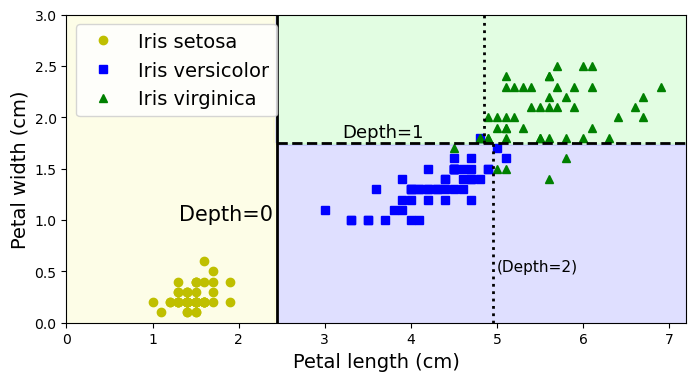

In [75]:
import numpy as np
import matplotlib.pyplot as plt

# extra code – just formatting details
from matplotlib.colors import ListedColormap
custom_cmap = ListedColormap(['#fafab0', '#9898ff', '#a0faa0'])
plt.figure(figsize=(8, 4))

lengths, widths = np.meshgrid(np.linspace(0, 7.2, 100), np.linspace(0, 3, 100))
X_iris_all = np.c_[lengths.ravel(), widths.ravel()]
y_pred = tree_clf.predict(X_iris_all).reshape(lengths.shape)
plt.contourf(lengths, widths, y_pred, alpha=0.3, cmap=custom_cmap)
for idx, (name, style) in enumerate(zip(iris.target_names, ("yo", "bs", "g^"))):
    plt.plot(X_iris[:, 0][y_iris == idx], X_iris[:, 1][y_iris == idx],
             style, label=f"Iris {name}")

# extra code – this section beautifies Figure 5–2
tree_clf_deeper = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_clf_deeper.fit(X_iris, y_iris)
th0, th1, th2a, th2b = tree_clf_deeper.tree_.threshold[[0, 2, 3, 6]]
plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.plot([th0, th0], [0, 3], "k-", linewidth=2)
plt.plot([th0, 7.2], [th1, th1], "k--", linewidth=2)
plt.plot([th2a, th2a], [0, th1], "k:", linewidth=2)
plt.plot([th2b, th2b], [th1, 3], "k:", linewidth=2)
plt.text(th0 - 0.05, 1.0, "Depth=0", horizontalalignment="right", fontsize=15)
plt.text(3.2, th1 + 0.02, "Depth=1", verticalalignment="bottom", fontsize=13)
plt.text(th2a + 0.05, 0.5, "(Depth=2)", fontsize=11)
plt.axis([0, 7.2, 0, 3])
plt.legend()

plt.show()

In [65]:
print("\n" + "=" * 80)
print("BÖLÜM 5: SINIF OLASILIKLARI")
print("=" * 80)

# Belirli bir örnek için sınıf olasılıklarını al
örnek = [[5, 1.5]]
olasılıklar = tree_clf.predict_proba(örnek)
# predict_proba() döndürür:
# [[p_class_0, p_class_1, p_class_2]]
# p_class_i: i sınıfına ait olma olasılığı

print(f"\n📊 Örnek [{örnek[0][0]}, {örnek[0][1]}] için Sınıf Olasılıkları:")
for class_idx, (class_name, prob) in enumerate(
    zip(iris.target_names, olasılıklar[0])
):
    print(f"   {class_name:12s}: {prob:6.1%} {'█' * int(prob * 20)}")

print(f"\n   → En yüksek olasılık: {iris.target_names[np.argmax(olasılıklar[0])]}")

# Olasılıklar nasıl hesaplanır?
print(f"\n🧮 Olasılık Hesaplaması Açıklaması:")
print(f"   Örnek, aşağıdaki yaprak düğüme ulaşır:")
print(f"   - Setosa: 0 örnek")
print(f"   - Versicolor: 49 örnek")
print(f"   - Virginica: 5 örnek")
print(f"   - Toplam: 54 örnek")
print(f"")
print(f"   Olasılıklar = Sınıf Sayısı / Toplam Sayı")
print(f"   - P(setosa) = 0/54 = 0.0")
print(f"   - P(versicolor) = 49/54 = {49/54:.3f}")
print(f"   - P(virginica) = 5/54 = {5/54:.3f}")

# Çoklu örnekler için olasılıklar
örnekler = np.array([
    [1.5, 0.5],
    [5.0, 1.5],
])

olasılıklar_çoklu = tree_clf.predict_proba(örnekler)

print(f"\n📊 Çoklu Örnekler için Olasılıklar:")
for i, (örnek, probs) in enumerate(zip(örnekler, olasılıklar_çoklu)):
    tahmin = iris.target_names[np.argmax(probs)]
    print(f"   Örnek {i+1} [{örnek[0]:.1f}, {örnek[1]:.1f}]:")
    for class_name, prob in zip(iris.target_names, probs):
        print(f"      {class_name:12s}: {prob:.3f}")



BÖLÜM 5: SINIF OLASILIKLARI

📊 Örnek [5, 1.5] için Sınıf Olasılıkları:
   setosa      :   0.0% 
   versicolor  :  90.7% ██████████████████
   virginica   :   9.3% █

   → En yüksek olasılık: versicolor

🧮 Olasılık Hesaplaması Açıklaması:
   Örnek, aşağıdaki yaprak düğüme ulaşır:
   - Setosa: 0 örnek
   - Versicolor: 49 örnek
   - Virginica: 5 örnek
   - Toplam: 54 örnek

   Olasılıklar = Sınıf Sayısı / Toplam Sayı
   - P(setosa) = 0/54 = 0.0
   - P(versicolor) = 49/54 = 0.907
   - P(virginica) = 5/54 = 0.093

📊 Çoklu Örnekler için Olasılıklar:
   Örnek 1 [1.5, 0.5]:
      setosa      : 1.000
      versicolor  : 0.000
      virginica   : 0.000
   Örnek 2 [5.0, 1.5]:
      setosa      : 0.000
      versicolor  : 0.907
      virginica   : 0.093


In [67]:
print("\n" + "=" * 80)
print("BÖLÜM 6: AĞAÇ YAPISINA ERIŞIM VE ANALİZ")
print("=" * 80)

tree = tree_clf.tree_  # Ağacın iç yapısına eriş

print(f"\n🔧 Ağaç Özellikleri:")
print(f"   - Düğüm sayısı: {tree.node_count}")
print(f"   - Maksimum derinlik: {tree.max_depth}")
print(f"   - Sınıf sayısı: {tree.max_n_classes}")
print(f"   - Özellik sayısı: {tree.n_features}")
print(f"   - Yaprak düğüm sayısı: {tree.n_leaves}")

print(f"\n📋 Tüm Düğümlerin Bilgileri:\n")
print(f"{'Düğüm':<6} {'Özellik':<12} {'Eşik':<8} {'Gini':<8} {'Örnekler':<10} {'Değer'}")
print(f"{'─'*6} {'─'*12} {'─'*8} {'─'*8} {'─'*10} {'─'*40}")

for i in range(tree.node_count):
    feature = tree.feature[i]
    threshold = tree.threshold[i]
    gini = tree.impurity[i]
    samples = tree.n_node_samples[i]
    value = tree.value[i][0]
    
    # Özellik adı veya yaprak göstergesi
    if feature == -2:
        feature_name = "YAPRAK"
    else:
        feature_names = ["petal length", "petal width"]
        feature_name = feature_names[feature]
    
    # Eşik değeri (yaprak için -)
    threshold_str = f"{threshold:.2f}" if feature != -2 else "-"
    
    print(f"{i:<6} {feature_name:<12} {threshold_str:<8} {gini:<8.3f} {samples:<10} {value}")

# Yaprak düğümleri bul
print(f"\n🍃 Yaprak Düğümleri:")
is_leaf = tree.children_left == tree.children_right
leaf_indices = np.arange(tree.node_count)[is_leaf]
print(f"   Yaprak düğüm indeksleri: {leaf_indices}")

for leaf_idx in leaf_indices:
    samples = tree.n_node_samples[leaf_idx]
    value = tree.value[leaf_idx][0]
    predicted_class = np.argmax(value)
    print(f"   Düğüm {leaf_idx}: {samples} örnek, {iris.target_names[predicted_class]}")

# Bölüm düğümleri (split nodes)
print(f"\n⚡ Bölüm Düğümleri (Split Nodes):")
split_nodes_mask = tree.children_left != tree.children_right
split_indices = np.arange(tree.node_count)[split_nodes_mask]

for split_idx in split_indices:
    feature_idx = tree.feature[split_idx]
    threshold = tree.threshold[split_idx]
    feature_names = ["petal length", "petal width"]
    print(f"   Düğüm {split_idx}: {feature_names[feature_idx]} ≤ {threshold:.2f}")




BÖLÜM 6: AĞAÇ YAPISINA ERIŞIM VE ANALİZ

🔧 Ağaç Özellikleri:
   - Düğüm sayısı: 5
   - Maksimum derinlik: 2
   - Sınıf sayısı: 3
   - Özellik sayısı: 2
   - Yaprak düğüm sayısı: 3

📋 Tüm Düğümlerin Bilgileri:

Düğüm  Özellik      Eşik     Gini     Örnekler   Değer
────── ──────────── ──────── ──────── ────────── ────────────────────────────────────────
0      petal length 2.45     0.667    150        [50. 50. 50.]
1      YAPRAK       -        0.000    50         [50.  0.  0.]
2      petal width  1.75     0.500    100        [ 0. 50. 50.]
3      YAPRAK       -        0.168    54         [ 0. 49.  5.]
4      YAPRAK       -        0.043    46         [ 0.  1. 45.]

🍃 Yaprak Düğümleri:
   Yaprak düğüm indeksleri: [1 3 4]
   Düğüm 1: 50 örnek, setosa
   Düğüm 3: 54 örnek, versicolor
   Düğüm 4: 46 örnek, virginica

⚡ Bölüm Düğümleri (Split Nodes):
   Düğüm 0: petal length ≤ 2.45
   Düğüm 2: petal width ≤ 1.75


In [68]:
print("\n" + "=" * 80)
print("BÖLÜM 7: AĞAÇ DERINLIĞI HESAPLAMA")
print("=" * 80)

def hesapla_derinlik(tree_clf):
    """
    Karar ağacında her düğümün derinliğini hesapla
    
    Parametreler:
        tree_clf: Eğitilmiş DecisionTreeClassifier
    
    Döndürür:
        depth: numpy array, her düğümün derinliği
    
    İşleyiş:
        1. Stack kullanarak derinlik-önce (depth-first) gezinti yap
        2. Kök düğümü derinlik 0 ile başlat
        3. Her düğümün çocuklarını stack'e ekle (derinlik+1)
        4. Stack boşalana kadar devam et
    """
    tree = tree_clf.tree_
    depth = np.zeros(tree.node_count)  # Her düğümün derinliğini sakla
    stack = [(0, 0)]  # (düğüm_indeksi, derinlik) tuple'ları
    
    while stack:  # Stack boş değilse devam et
        node, node_depth = stack.pop()
        depth[node] = node_depth
        
        # Eğer bu bir yaprak değilse (bölüm düğümüyse)
        # Sol ve sağ çocuklarını stack'e ekle
        if tree.children_left[node] != tree.children_right[node]:
            left_child = tree.children_left[node]
            right_child = tree.children_right[node]
            
            # Çocukları derinlik+1 ile stack'e ekle
            stack.append((left_child, node_depth + 1))
            stack.append((right_child, node_depth + 1))
    
    return depth

depth = hesapla_derinlik(tree_clf)

print(f"\n📊 Her Düğümün Derinliği:")
for i in range(tree.node_count):
    print(f"   Düğüm {i}: Derinlik {int(depth[i])}")

print(f"\n📈 Derinliğe Göre Düğümler:")
for d in range(int(tree.max_depth) + 1):
    nodes_at_depth = np.arange(tree.node_count)[depth == d]
    print(f"   Derinlik {d}: {nodes_at_depth} (Toplam: {len(nodes_at_depth)} düğüm)")



BÖLÜM 7: AĞAÇ DERINLIĞI HESAPLAMA

📊 Her Düğümün Derinliği:
   Düğüm 0: Derinlik 0
   Düğüm 1: Derinlik 1
   Düğüm 2: Derinlik 1
   Düğüm 3: Derinlik 2
   Düğüm 4: Derinlik 2

📈 Derinliğe Göre Düğümler:
   Derinlik 0: [0] (Toplam: 1 düğüm)
   Derinlik 1: [1 2] (Toplam: 2 düğüm)
   Derinlik 2: [3 4] (Toplam: 2 düğüm)


In [69]:
print("\n" + "=" * 80)
print("BÖLÜM 8: GİNİ İMPURİTY (SAFSIZLIK) HESAPLAMA")
print("=" * 80)

def hesapla_gini(örnekler):
    """
    Gini Impurity'yi hesapla
    
    Formül: G = 1 - Σ(p_k)²
    Burada p_k: k sınıfının oranı
    
    Örnek:
        - Saf düğüm (sadece 1 sınıf): G = 0
        - Tamamen karışık (50-50): G = 0.5 (2 sınıf için)
    """
    toplam = np.sum(örnekler)
    if toplam == 0:
        return 0
    
    oranlar = örnekler / toplam
    gini = 1 - np.sum(oranlar ** 2)
    return gini

print("\n🧮 Gini Impurity Örnekleri:\n")

test_durumları = [
    ([50, 0, 0], "Tamamen Saf (Sadece Setosa)"),
    ([0, 50, 0], "Tamamen Saf (Sadece Versicolor)"),
    ([0, 49, 5], "Karışık (49 Versicolor, 5 Virginica)"),
    ([10, 10, 10], "Tamamen Karışık (Eşit Dağılım)"),
]

for örnekler, açıklama in test_durumları:
    örnekler_arr = np.array(örnekler)
    gini = hesapla_gini(örnekler_arr)
    toplam = np.sum(örnekler)
    oranlar = örnekler_arr / toplam
    
    print(f"Durum: {açıklama}")
    print(f"   Örnekler: Setosa={örnekler[0]}, Versicolor={örnekler[1]}, Virginica={örnekler[2]}")
    print(f"   Oranlar: {oranlar[0]:.3f}, {oranlar[1]:.3f}, {oranlar[2]:.3f}")
    print(f"   Gini = 1 - ({oranlar[0]:.3f}² + {oranlar[1]:.3f}² + {oranlar[2]:.3f}²)")
    print(f"   Gini = {gini:.3f}")
    
    if gini == 0:
        print(f"   ✓ TAMAMEN SAF")
    elif gini < 0.3:
        print(f"   ≈ Oldukça Saf")
    elif gini < 0.7:
        print(f"   ≈ Karışık")
    else:
        print(f"   ✗ Çok Karışık")
    print()


BÖLÜM 8: GİNİ İMPURİTY (SAFSIZLIK) HESAPLAMA

🧮 Gini Impurity Örnekleri:

Durum: Tamamen Saf (Sadece Setosa)
   Örnekler: Setosa=50, Versicolor=0, Virginica=0
   Oranlar: 1.000, 0.000, 0.000
   Gini = 1 - (1.000² + 0.000² + 0.000²)
   Gini = 0.000
   ✓ TAMAMEN SAF

Durum: Tamamen Saf (Sadece Versicolor)
   Örnekler: Setosa=0, Versicolor=50, Virginica=0
   Oranlar: 0.000, 1.000, 0.000
   Gini = 1 - (0.000² + 1.000² + 0.000²)
   Gini = 0.000
   ✓ TAMAMEN SAF

Durum: Karışık (49 Versicolor, 5 Virginica)
   Örnekler: Setosa=0, Versicolor=49, Virginica=5
   Oranlar: 0.000, 0.907, 0.093
   Gini = 1 - (0.000² + 0.907² + 0.093²)
   Gini = 0.168
   ≈ Oldukça Saf

Durum: Tamamen Karışık (Eşit Dağılım)
   Örnekler: Setosa=10, Versicolor=10, Virginica=10
   Oranlar: 0.333, 0.333, 0.333
   Gini = 1 - (0.333² + 0.333² + 0.333²)
   Gini = 0.667
   ≈ Karışık



BÖLÜM 9: KARAR SINIRI GÖRSELLEŞTIRMESI

📊 Karar Sınırları Grafik Hazırlanıyor...
✓ Grafik oluşturuldu (görmek için plt.show() çalıştırın)


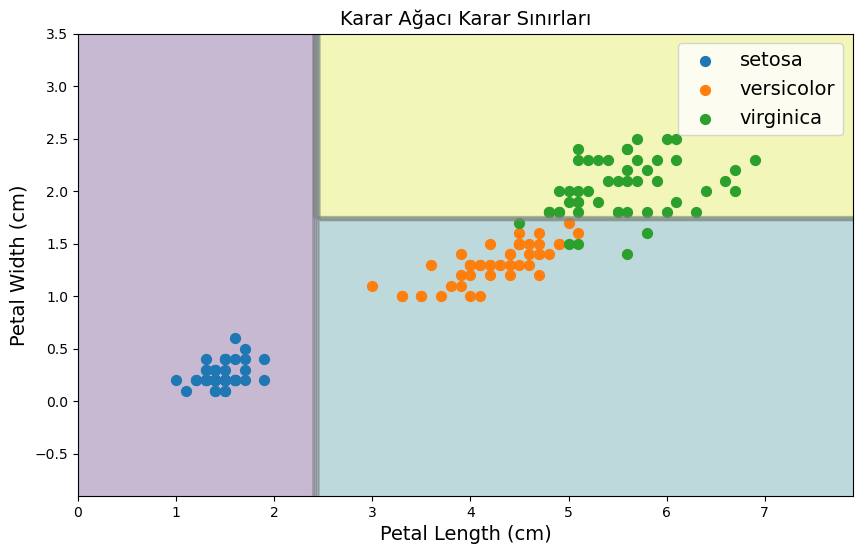

In [72]:
print("=" * 80)
print("BÖLÜM 9: KARAR SINIRI GÖRSELLEŞTIRMESI")
print("=" * 80)

def karar_siniri_çiz(clf, X, y, axes=None):
    """
    Karar ağacının karar sınırlarını görselleştir
    
    Parametreler:
        clf: Eğitilmiş sınıflandırıcı
        X: Eğitim verisi (n_samples, 2)
        y: Sınıflar (n_samples,)
        axes: Çizim sınırları [x_min, x_max, y_min, y_max]
    """
    if axes is None:
        axes = [X[:, 0].min() - 1, X[:, 0].max() + 1,
                X[:, 1].min() - 1, X[:, 1].max() + 1]
    
    # Mesh ağı oluştur
    x1 = np.linspace(axes[0], axes[1], 100)
    x2 = np.linspace(axes[2], axes[3], 100)
    X1, X2 = np.meshgrid(x1, x2)
    X_mesh = np.c_[X1.ravel(), X2.ravel()]
    
    # Mesh üzerinde tahmin yap
    y_mesh = clf.predict(X_mesh).reshape(X1.shape)
    
    # Karar sınırlarını çiz
    plt.contourf(X1, X2, y_mesh, alpha=0.3, cmap='viridis')
    plt.contour(X1, X2, y_mesh, colors='gray', alpha=0.5)
    
    # Eğitim örneklerini çiz
    for class_idx in np.unique(y):
        plt.scatter(X[y == class_idx, 0], X[y == class_idx, 1],
                   label=iris.target_names[class_idx], s=50)
    
    plt.xlabel("Petal Length (cm)")
    plt.ylabel("Petal Width (cm)")
    plt.title("Karar Ağacı Karar Sınırları")
    plt.axis(axes)
    plt.legend()

print("\n📊 Karar Sınırları Grafik Hazırlanıyor...")
plt.figure(figsize=(10, 6))
karar_siniri_çiz(tree_clf, X_iris, y_iris)
# plt.savefig('karar_siniri.png', dpi=100, bbox_inches='tight')
# plt.show()
print("✓ Grafik oluşturuldu (görmek için plt.show() çalıştırın)")


## Regression

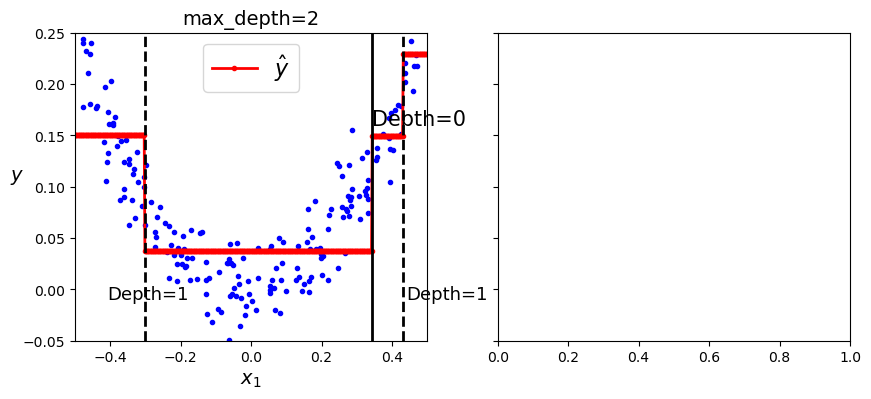

In [86]:


def plot_regression_predictions(tree_reg, X, y, axes=[-0.5, 0.5, -0.05, 0.25]):
    x1 = np.linspace(axes[0], axes[1], 500).reshape(-1, 1)
    y_pred = tree_reg.predict(x1)
    plt.axis(axes)
    plt.xlabel("$x_1$")
    plt.plot(X, y, "b.")
    plt.plot(x1, y_pred, "r.-", linewidth=2, label=r"$\hat{y}$")

fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharey=True)
plt.sca(axes[0])
plot_regression_predictions(tree_reg, X_quad, y_quad)

th0, th1a, th1b = tree_reg.tree_.threshold[[0, 1, 4]]
for split, style in ((th0, "k-"), (th1a, "k--"), (th1b, "k--")):
    plt.plot([split, split], [-0.05, 0.25], style, linewidth=2)
plt.text(th0, 0.16, "Depth=0", fontsize=15)
plt.text(th1a + 0.01, -0.01, "Depth=1", horizontalalignment="center", fontsize=13)
plt.text(th1b + 0.01, -0.01, "Depth=1", fontsize=13)
plt.ylabel("$y$", rotation=0)
plt.legend(loc="upper center", fontsize=16)
plt.title("max_depth=2")

plt.show()

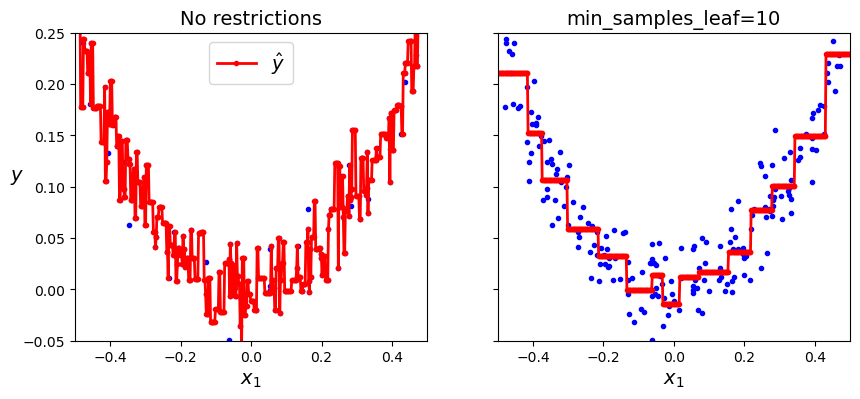

In [81]:


tree_reg1 = DecisionTreeRegressor(random_state=42)
tree_reg2 = DecisionTreeRegressor(random_state=42, min_samples_leaf=10)
tree_reg1.fit(X_quad, y_quad)
tree_reg2.fit(X_quad, y_quad)

x1 = np.linspace(-0.5, 0.5, 500).reshape(-1, 1)
y_pred1 = tree_reg1.predict(x1)
y_pred2 = tree_reg2.predict(x1)

fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharey=True)

plt.sca(axes[0])
plt.plot(X_quad, y_quad, "b.")
plt.plot(x1, y_pred1, "r.-", linewidth=2, label=r"$\hat{y}$")
plt.axis([-0.5, 0.5, -0.05, 0.25])
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.legend(loc="upper center")
plt.title("No restrictions")

plt.sca(axes[1])
plt.plot(X_quad, y_quad, "b.")
plt.plot(x1, y_pred2, "r.-", linewidth=2, label=r"$\hat{y}$")
plt.axis([-0.5, 0.5, -0.05, 0.25])
plt.xlabel("$x_1$")
plt.title(f"min_samples_leaf={tree_reg2.min_samples_leaf}")

plt.show()

## AY VERİ SETİ ÜZERİNDEKİ ÖRNEĞİN TAM DETAYLI KODLARI

In [71]:
print("\n" + "=" * 80)
print("BÖLÜM 10: DÜZENLILEŞTIRME VE AŞIRI UYUM")
print("=" * 80)

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

# Ay şeklinde 150 örnek oluştur
X_moons, y_moons = make_moons(n_samples=150, noise=0.2, random_state=42)

# Eğitim ve test verilerine böl
X_train, X_test, y_train, y_test = train_test_split(
    X_moons, y_moons, test_size=0.2, random_state=42
)

print(f"\n📊 Ay Veri Seti Bilgileri:")
print(f"   - Toplam örnek: {len(X_moons)}")
print(f"   - Eğitim örneği: {len(X_train)}")
print(f"   - Test örneği: {len(X_test)}")
print(f"   - Özellik sayısı: 2")
print(f"   - Sınıf sayısı: 2")

# Aşırı Uyum Yapan Model (Sınırlandırma Yok)
print(f"\n⚠️  AŞIRI UYUM YAPAN MODEL (Sınırlandırma Yok):")
tree_overfit = DecisionTreeClassifier(random_state=42)
tree_overfit.fit(X_train, y_train)

train_acc_overfit = tree_overfit.score(X_train, y_train)
test_acc_overfit = tree_overfit.score(X_test, y_test)

print(f"   - Eğitim Doğruluğu: {train_acc_overfit:.1%}")
print(f"   - Test Doğruluğu: {test_acc_overfit:.1%}")
print(f"   - Fark: {(train_acc_overfit - test_acc_overfit):.1%} (ÇIKAR KÖTÜDÜr!)")
print(f"   - Ağaç Derinliği: {tree_overfit.tree_.max_depth}")
print(f"   - Yaprak Sayısı: {tree_overfit.tree_.n_leaves}")

# Düzenlileştirilmiş Model (min_samples_leaf=5)
print(f"\n✓ DÜZENLILEŞTIRILMIŞ MODEL (min_samples_leaf=5):")
tree_regular = DecisionTreeClassifier(min_samples_leaf=5, random_state=42)
tree_regular.fit(X_train, y_train)

train_acc_regular = tree_regular.score(X_train, y_train)
test_acc_regular = tree_regular.score(X_test, y_test)

print(f"   - Eğitim Doğruluğu: {train_acc_regular:.1%}")
print(f"   - Test Doğruluğu: {test_acc_regular:.1%}")
print(f"   - Fark: {(train_acc_regular - test_acc_regular):.1%} (İYİ!)")
print(f"   - Ağaç Derinliği: {tree_regular.tree_.max_depth}")
print(f"   - Yaprak Sayısı: {tree_regular.tree_.n_leaves}")

print(f"\n📊 Karşılaştırma:")
print(f"   {'Metrik':<20} {'Aşırı Uyum':<15} {'Düzenlileştirilmiş':<15}")
print(f"   {'-'*20} {'-'*15} {'-'*15}")
print(f"   {'Eğitim Doğruluğu':<20} {train_acc_overfit:.1%}{'':<8} {train_acc_regular:.1%}")
print(f"   {'Test Doğruluğu':<20} {test_acc_overfit:.1%}{'':<8} {test_acc_regular:.1%}")
print(f"   {'Genelleme Farkı':<20} {(train_acc_overfit - test_acc_overfit):.1%}{'':<8} {(train_acc_regular - test_acc_regular):.1%}")



BÖLÜM 10: DÜZENLILEŞTIRME VE AŞIRI UYUM

📊 Ay Veri Seti Bilgileri:
   - Toplam örnek: 150
   - Eğitim örneği: 120
   - Test örneği: 30
   - Özellik sayısı: 2
   - Sınıf sayısı: 2

⚠️  AŞIRI UYUM YAPAN MODEL (Sınırlandırma Yok):
   - Eğitim Doğruluğu: 100.0%
   - Test Doğruluğu: 90.0%
   - Fark: 10.0% (ÇIKAR KÖTÜDÜr!)
   - Ağaç Derinliği: 7
   - Yaprak Sayısı: 15

✓ DÜZENLILEŞTIRILMIŞ MODEL (min_samples_leaf=5):
   - Eğitim Doğruluğu: 91.7%
   - Test Doğruluğu: 83.3%
   - Fark: 8.3% (İYİ!)
   - Ağaç Derinliği: 6
   - Yaprak Sayısı: 11

📊 Karşılaştırma:
   Metrik               Aşırı Uyum      Düzenlileştirilmiş
   -------------------- --------------- ---------------
   Eğitim Doğruluğu     100.0%         91.7%
   Test Doğruluğu       90.0%         83.3%
   Genelleme Farkı      10.0%         8.3%


### Diğer örnekler

In [73]:
print("\n" + "=" * 80)
print("BÖLÜM 11: KARAR AĞACI REGRESYONU")
print("=" * 80)

from sklearn.tree import DecisionTreeRegressor

# İkinci dereceden fonksiyon + gürültü
rng = np.random.default_rng(seed=42)
X_quad = rng.random((200, 1)) - 0.5  # -0.5 ile 0.5 arasında
y_quad = X_quad ** 2 + 0.025 * rng.standard_normal((200, 1))

print(f"\n📊 Veri Seti: y = x² + gürültü")
print(f"   - Örnek sayısı: {len(X_quad)}")
print(f"   - X aralığı: [{X_quad.min():.2f}, {X_quad.max():.2f}]")
print(f"   - y aralığı: [{y_quad.min():.4f}, {y_quad.max():.4f}]")

# Regresyon Ağacı Eğit
tree_reg = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_reg.fit(X_quad, y_quad)

print(f"\n🌳 Regresyon Ağacı Özellikleri:")
print(f"   - Derinlik: {tree_reg.tree_.max_depth}")
print(f"   - Düğüm Sayısı: {tree_reg.tree_.node_count}")
print(f"   - Yaprak Sayısı: {tree_reg.tree_.n_leaves}")

# Test örnekleri
X_test_reg = np.array([[-0.25], [0.0], [0.25]])
y_pred_reg = tree_reg.predict(X_test_reg)
y_true_reg = X_test_reg ** 2

print(f"\n🔮 Tahmin Örnekleri:")
print(f"   {'X':<8} {'Tahmin':<12} {'Gerçek':<12} {'Hata':<10}")
print(f"   {'-'*8} {'-'*12} {'-'*12} {'-'*10}")
for x, y_pred, y_true in zip(X_test_reg, y_pred_reg, y_true_reg):
    hata = abs(y_pred - y_true)
    print(f"   {x[0]:<8.2f} {y_pred:<12.4f} {y_true[0]:<12.4f} {hata:<10.4f}")

# MSE Hesapla
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_quad, tree_reg.predict(X_quad))
print(f"\n📈 Eğitim MSE (Mean Squared Error): {mse:.6f}")



BÖLÜM 11: KARAR AĞACI REGRESYONU

📊 Veri Seti: y = x² + gürültü
   - Örnek sayısı: 200
   - X aralığı: [-0.49, 0.49]
   - y aralığı: [-0.0566, 0.2886]

🌳 Regresyon Ağacı Özellikleri:
   - Derinlik: 2
   - Düğüm Sayısı: 7
   - Yaprak Sayısı: 4

🔮 Tahmin Örnekleri:
   X        Tahmin       Gerçek       Hata      
   -------- ------------ ------------ ----------


TypeError: unsupported format string passed to numpy.ndarray.__format__

In [74]:
print("\n" + "=" * 80)
print("BÖLÜM 12: HİPERPARAMETRE TUNING (GRID SEARCH)")
print("=" * 80)

from sklearn.model_selection import GridSearchCV

# Ay veri seti
X_moons_large, y_moons_large = make_moons(n_samples=1000, noise=0.3, random_state=42)
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_moons_large, y_moons_large, test_size=0.2, random_state=42
)

print(f"\n📊 Veri Seti:")
print(f"   - Eğitim örneği: {len(X_train_m)}")
print(f"   - Test örneği: {len(X_test_m)}")

# Denenecek hiperparametreler
param_grid = {
    'max_depth': [2, 3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

print(f"\n🔧 Denenecek Hiperparameter Kombinasyonları:")
kombinasyon_sayısı = 1
for param, değerler in param_grid.items():
    print(f"   - {param}: {değerler}")
    kombinasyon_sayısı *= len(değerler)
print(f"   - Toplam kombinasyon: {kombinasyon_sayısı}")

# Grid Search başlat (3 kat çapraz doğrulama)
print(f"\n⏳ Grid Search çalışıyor (3-Fold CV, {kombinasyon_sayısı} kombinasyon)...")

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=3,                  # 3 kat çapraz doğrulama
    scoring='accuracy',    # Maksimize etmek istediğimiz metrik
    n_jobs=-1             # Tüm CPU çekirdekleri kullan
)

grid_search.fit(X_train_m, y_train_m)

print(f"✓ Grid Search tamamlandı!\n")

# En iyi parametreleri al
print(f"🏆 En İyi Hiperparametreler:")
for param, value in grid_search.best_params_.items():
    print(f"   - {param}: {value}")

print(f"\n📊 En İyi CV Skoru: {grid_search.best_score_:.1%}")

# En iyi modeli test et
best_model = grid_search.best_estimator_
test_score = best_model.score(X_test_m, y_test_m)

print(f"📊 Test Seti Doğruluğu: {test_score:.1%}")

# Tüm sonuçları göster (top 5)
print(f"\n🔝 En İyi 5 Sonuç:")
results = grid_search.cv_results_
top_5_indices = np.argsort(results['mean_test_score'])[-5:][::-1]

print(f"{'Sıra':<6} {'max_depth':<12} {'min_split':<12} {'min_leaf':<12} {'CV Skoru':<12}")
print(f"{'-'*6} {'-'*12} {'-'*12} {'-'*12} {'-'*12}")

for sıra, idx in enumerate(top_5_indices, 1):
    params = results['params'][idx]
    score = results['mean_test_score'][idx]
    print(f"{sıra:<6} {params['max_depth']:<12} {params['min_samples_split']:<12} "
          f"{params['min_samples_leaf']:<12} {score:.4f}")



BÖLÜM 12: HİPERPARAMETRE TUNING (GRID SEARCH)

📊 Veri Seti:
   - Eğitim örneği: 800
   - Test örneği: 200

🔧 Denenecek Hiperparameter Kombinasyonları:
   - max_depth: [2, 3, 4, 5]
   - min_samples_split: [2, 5, 10]
   - min_samples_leaf: [1, 2, 4]
   - Toplam kombinasyon: 36

⏳ Grid Search çalışıyor (3-Fold CV, 36 kombinasyon)...
✓ Grid Search tamamlandı!

🏆 En İyi Hiperparametreler:
   - max_depth: 5
   - min_samples_leaf: 2
   - min_samples_split: 2

📊 En İyi CV Skoru: 90.5%
📊 Test Seti Doğruluğu: 88.0%

🔝 En İyi 5 Sonuç:
Sıra   max_depth    min_split    min_leaf     CV Skoru    
------ ------------ ------------ ------------ ------------
1      5            10           4            0.9050
2      5            2            4            0.9050
3      5            10           2            0.9050
4      5            5            2            0.9050
5      5            2            2            0.9050


## KİTAP SONU ALIŞTIRMA SORULARI VE CEVAPLARI

### 1️⃣ Soru

## Bir milyon örnek içeren (kısıtlamasız eğitilmiş) bir karar ağacının yaklaşık derinliği nedir?


## Cevap:

Dengeli bir ikili ağacın (binary tree) derinliği yaklaşık olarak:


\log_2(m)


Burada m = yaprak sayısıdır.

Scikit-Learn’deki Decision Tree’ler binary (ikili) bölme yapar.
Kısıt yoksa (max_depth, min_samples_leaf vs. yoksa) ağaç genellikle:
	•	Her eğitim örneği için bir yaprak üretir.
	•	Yani yaklaşık m = örnek sayısı kadar yaprak olur.

Eğer:

m = 1.000.000 = 10^6



\log_2(10^6) ≈ 20


 Yani yaklaşık 20 derinlik.

Ancak ağaç tamamen dengeli olmaz, bu yüzden gerçek derinlik 20’den biraz fazla olabilir.

## 2️⃣ Soru

Bir düğümün Gini impurity’si genellikle ebeveyninden düşük müdür? Her zaman mı düşüktür?

### Cevap:

🔹 Genellikle daha düşüktür.
🔹 Ama her zaman değil.

### Neden?

CART algoritması, şu maliyeti minimize eder:


## Amaç:
 Çocuk düğümlerin ağırlıklı Gini’sini azaltmaktır.

Bu şu anlama gelir:
	•	Bir çocuk düğümün Gini’si ebeveynden yüksek olabilir.
	•	Ama diğer çocuk çok saf (pure) ise toplam ağırlıklı Gini düşebilir.

Örnek:

Parent düğüm:
4 tane A, 1 tane B


Gini = 1 - (4/5)^2 - (1/5)^2 = 0.32


Bölme sonrası:

Child 1: A, B

Gini = 0.5


Child 2: A, A, A

Gini = 0


Toplam ağırlıklı Gini:


(2/5 × 0.5) + (3/5 × 0) = 0.2


0.2 < 0.32

Yani toplam impurity düşmüş oldu.

## 3️⃣ Soru

Decision Tree overfitting yapıyorsa max_depth azaltmak iyi fikir mi?


Evet.

Overfitting demek:
	•	Model eğitim verisini ezberliyor
	•	Çok derin ağaç oluşmuş
	•	Yapraklar çok küçük

max_depth’i azaltmak:
	•	Ağacı kısıtlar
	•	Modeli regularize eder
	•	Genelleme performansını artırır

 Evet, iyi bir çözümdür.

## 4️⃣ Soru

Decision Tree underfitting yapıyorsa feature scaling işe yarar mı?


### Cevap:

Hayır.

Decision Tree’ler:
	•	Ölçekten etkilenmez
	•	Mesafeye bakmaz
	•	Sadece eşik (threshold) karşılaştırması yapar

Örnek:
x > 5 mi?
x > 5000 mi?

Ölçek değişse de mantık aynıdır.

 Scaling zaman kaybıdır.

## 5️⃣ Soru

1 milyon veri 1 saat sürüyorsa, 10 milyon veri ne kadar sürer?


## 6️⃣ Soru

Feature sayısı iki katına çıkarsa süre ne olur?
